# setup

In [ ]:
# =========================
# 1. Setup
# =========================
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_PATH = "/content/drive/MyDrive/Deep Learning Project/models/ntu60_hrnet.pkl"


# =========================
# 2. Load Data
# =========================
with open(MODEL_PATH, 'rb') as f:
    data = pickle.load(f)

In [ ]:
LR=0.1
EPOCHS=5
NUM_WORKERS=2
NUM_CLASSES=60
BATCH_SIZE=16

# ST-GCN
LR=0.1
EPOCHS=5
NUM_WORKERS=2
NUM_CLASSES=60
BATCH_SIZE=16
Train Loss: 0.8239 | Train Acc: 72.83%
Val Loss: 0.8394 | Val Acc: 73.50%
Checkpoint saved! Best validation accuracy: 73.50%


In [ ]:
import torch
import os

checkpoint_path = os.path.join(os.path.dirname(MODEL_PATH), 'multi_stream_stgcn_checkpoint.pth')

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    print(f"--- Checkpoint Verification ---")
    print(f"Keys in checkpoint: {list(checkpoint.keys())}")
    print(f"Last saved epoch: {checkpoint.get('epoch')}")
    print(f"Best validation accuracy recorded: {checkpoint.get('best_val_acc'):.2f}%")

    if 'model_state_dict' in checkpoint and 'optimizer_state_dict' in checkpoint:
        print("✅ Success: Model and Optimizer states found.")
    else:
        print("❌ Error: Missing critical state dictionaries.")
else:
    print(f"No checkpoint found at {checkpoint_path}. Run main() first to generate one.")

--- Checkpoint Verification ---
Keys in checkpoint: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_val_acc']
Last saved epoch: 2
Best validation accuracy recorded: 61.31%
✅ Success: Model and Optimizer states found.


In [ ]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class NTUDataset(Dataset):
    def __init__(self, data_path, split_name='xsub_train', max_frames=64, num_joints=17, max_persons=2, is_training=True):
        self.data_path = data_path
        self.split_name = split_name
        self.max_frames = max_frames
        self.num_joints = num_joints
        self.max_persons = max_persons
        self.is_training = is_training

        print(f"Loading data from {data_path} for split {split_name}...")
        with open(data_path, 'rb') as f:
            self.data = pickle.load(f)

        self.split_ids = set(self.data['split'][split_name])

        self.samples = []
        for ann in tqdm(self.data['annotations'], desc="Filtering split"):
            if ann['frame_dir'] in self.split_ids:
                self.samples.append(ann)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ann = self.samples[idx]
        kp = ann['keypoint'].copy() # (M, T, V, C)
        score = ann.get('keypoint_score', None)
        if score is not None:
            score = score.copy() # (M, T, V)

        M, T, V, C = kp.shape

        # Temporal Augmentation / Padding
        if T >= self.max_frames:
            if self.is_training:
                # Random crop
                start = np.random.randint(0, T - self.max_frames + 1)
            else:
                # Center crop
                start = (T - self.max_frames) // 2
            kp = kp[:, start:start+self.max_frames, :, :]
            if score is not None:
                score = score[:, start:start+self.max_frames, :]
        else:
            # Pad with zeros
            pad_len = self.max_frames - T
            pad_kp = np.zeros((M, pad_len, V, C), dtype=kp.dtype)
            kp = np.concatenate([kp, pad_kp], axis=1)
            if score is not None:
                pad_score = np.zeros((M, pad_len, V), dtype=score.dtype)
                score = np.concatenate([score, pad_score], axis=1)

        # Persons Padding / Truncation
        if M < self.max_persons:
            pad_m = self.max_persons - M
            pad_kp = np.zeros((pad_m, self.max_frames, V, C), dtype=kp.dtype)
            kp = np.concatenate([kp, pad_kp], axis=0)
            if score is not None:
                pad_score = np.zeros((pad_m, self.max_frames, V), dtype=score.dtype)
                score = np.concatenate([score, pad_score], axis=0)
        elif M > self.max_persons:
            kp = kp[:self.max_persons]
            if score is not None:
                score = score[:self.max_persons]

        # Normalization (Center to the first valid person's first valid frame nose)
        valid_mask = (kp.sum(axis=-1) != 0) # (M, T, V)
        if valid_mask.any():
            # Find first M and T that has valid data
            m_idx, t_idx, _ = np.where(valid_mask)
            first_m, first_t = m_idx[0], t_idx[0]
            center_joint = kp[first_m, first_t, 0, :].copy() # Assume nose is 0

            # Apply to all non-zero coordinates
            mask = np.expand_dims(valid_mask, axis=-1)
            kp = kp - center_joint * mask

        # Add score as third channel if available
        if score is not None:
            score = np.expand_dims(score, axis=-1)
            kp = np.concatenate([kp, score], axis=-1) # (M, T, V, 3)

        # Transpose to (C, T, V, M)
        kp = kp.transpose((3, 1, 2, 0))

        label = ann['label']

        return torch.tensor(kp, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

def get_hop_distance(num_node, edge, max_hop=1):
    A = np.zeros((num_node, num_node))
    for i, j in edge:
        A[j, i] = 1
        A[i, j] = 1

    hop_dis = np.zeros((num_node, num_node)) + np.inf
    transfer_mat = [np.linalg.matrix_power(A, d) for d in range(max_hop + 1)]
    arrive_mat = (np.stack(transfer_mat) > 0)
    for d in range(max_hop, -1, -1):
        hop_dis[arrive_mat[d]] = d
    return hop_dis

class Graph():
    def __init__(self, num_node=17, center=0):
        self.num_node = num_node
        self.center = center
        # COCO 17 joints connections
        self.inward = [(1, 0), (2, 0), (3, 1), (4, 2), (5, 0), (6, 0), (7, 5), (8, 6), (9, 7), (10, 8), (11, 5), (12, 6), (13, 11), (14, 12), (15, 13), (16, 14)]
        self.outward = [(j, i) for (i, j) in self.inward]
        self.edge = self.inward + self.outward
        self.hop_dis = get_hop_distance(self.num_node, self.edge, max_hop=1)
        self.A = self.get_spatial_graph()

    def get_spatial_graph(self):
        A = np.zeros((3, self.num_node, self.num_node))
        for i in range(self.num_node):
            for j in range(self.num_node):
                if self.hop_dis[j, i] == 0:
                    A[0, j, i] = 1
                elif self.hop_dis[j, i] == 1:
                    if self.hop_dis[j, self.center] < self.hop_dis[i, self.center]:
                        A[1, j, i] = 1
                    else:
                        A[2, j, i] = 1
        for i in range(3):
            D = A[i].sum(axis=1)
            D[D == 0] = 1
            D = D ** -1
            A[i] = A[i] * D.reshape(-1, 1)
        return A

class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, s_kernel_size=3, t_kernel_size=1, t_stride=1, t_padding=0):
        super().__init__()
        self.s_kernel_size = s_kernel_size
        self.conv = nn.Conv2d(in_channels, out_channels * s_kernel_size, kernel_size=(t_kernel_size, 1), padding=(t_padding, 0), stride=(t_stride, 1))

    def forward(self, x, A):
        x = self.conv(x)
        N, KC, T, V = x.size()
        C = KC // self.s_kernel_size
        x = x.view(N, self.s_kernel_size, C, T, V)
        x = torch.einsum('n k c t v, k v w -> n c t w', (x, A))
        return x.contiguous()

class st_gcn_block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, residual=True):
        super().__init__()
        self.sgcn = SpatialGraphConv(in_channels, out_channels, s_kernel_size=3)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, (9, 1), (stride, 1), (4, 0)),
            nn.BatchNorm2d(out_channels),
        )
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.sgcn(x, A)
        x = self.tcn(x)
        return self.relu(x + res)

class STGCN(nn.Module):
    def __init__(self, in_channels, num_classes, num_node=17, edge_importance_weighting=True):
        super().__init__()
        self.graph = Graph(num_node)
        A = torch.tensor(self.graph.A, dtype=torch.float32, requires_grad=False)
        self.register_buffer('A', A)

        self.data_bn = nn.BatchNorm1d(in_channels * num_node)

        self.st_gcn_networks = nn.ModuleList((
            st_gcn_block(in_channels, 64, residual=False),
            st_gcn_block(64, 64),
            st_gcn_block(64, 64),
            st_gcn_block(64, 64),
            st_gcn_block(64, 128, stride=2),
            st_gcn_block(128, 128),
            st_gcn_block(128, 128),
            st_gcn_block(128, 256, stride=2),
            st_gcn_block(256, 256),
            st_gcn_block(256, 256),
        ))

        if edge_importance_weighting:
            self.edge_importance = nn.ParameterList([
                nn.Parameter(torch.ones(self.A.size()))
                for i in self.st_gcn_networks
            ])
        else:
            self.edge_importance = [1] * len(self.st_gcn_networks)

        self.fcn = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        # x: N, C, T, V, M
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous() # N, M, V, C, T
        x = x.view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T)
        x = x.permute(0, 1, 3, 4, 2).contiguous()
        x = x.view(N * M, C, T, V)

        for gcn, importance in zip(self.st_gcn_networks, self.edge_importance):
            x = gcn(x, self.A * importance)

        # Global pooling
        x = F.avg_pool2d(x, x.size()[2:]) # N*M, 256, 1, 1
        x = x.view(N, M, -1, 1, 1).mean(dim=1) # N, 256, 1, 1

        x = self.fcn(x)
        x = x.view(N, -1)
        return x

class MultiStreamSTGCN(nn.Module):
    def __init__(self, in_channels, num_classes, num_node=17):
        super().__init__()
        # 3 Streams for Joint, Bone, and Velocity
        self.joint_model = STGCN(in_channels, num_classes, num_node)
        self.bone_model = STGCN(in_channels, num_classes, num_node)
        self.velocity_model = STGCN(in_channels, num_classes, num_node)

        # Bones mapping for COCO 17 joints (parent array)
        self.parents = [0, 0, 0, 1, 2, 0, 0, 5, 6, 7, 8, 5, 6, 11, 12, 13, 14]

    def get_bone_data(self, x):
        x_bone = torch.zeros_like(x)
        for v in range(x.size(3)): # V
            u = self.parents[v]
            x_bone[:, :, :, v, :] = x[:, :, :, v, :] - x[:, :, :, u, :]
        return x_bone

    def get_velocity_data(self, x):
        x_vel = torch.zeros_like(x)
        x_vel[:, :, :-1, :, :] = x[:, :, 1:, :, :] - x[:, :, :-1, :, :]
        return x_vel

    def forward(self, x):
        # Joint Stream
        out_joint = self.joint_model(x)

        # Bone Stream
        x_bone = self.get_bone_data(x)
        out_bone = self.bone_model(x_bone)

        # Velocity Stream
        x_vel = self.get_velocity_data(x)
        out_vel = self.velocity_model(x_vel)

        # Late Fusion
        out = out_joint + out_bone + out_vel
        return out

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i, (inputs, targets) in enumerate(tqdm(dataloader, desc="Training")):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    return total_loss / len(dataloader), acc

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    return total_loss / len(dataloader), acc

def main():
    # --- Configuration ---
    data_path = MODEL_PATH
    num_classes = NUM_CLASSES # NTU-60
    batch_size = BATCH_SIZE
    epochs = EPOCHS
    lr = LR
    # ---------------------

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Dataset and DataLoader
    train_dataset = NTUDataset(data_path, split_name='xsub_train', max_frames=64, is_training=True)
    val_dataset = NTUDataset(data_path, split_name='xsub_val', max_frames=64, is_training=False)

    sample_kp, _ = train_dataset[0]
    in_channels = sample_kp.size(0)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Model
    model = MultiStreamSTGCN(in_channels=in_channels, num_classes=num_classes).to(device)

    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 40], gamma=0.1)

    # Model saving setup
    output_dir = os.path.dirname(MODEL_PATH)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    saved_model_path = os.path.join(output_dir, 'multi_stream_stgcn_checkpoint.pth')

    start_epoch = 0
    best_val_acc = -1.0

    # History lists to store metrics
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    # Load full checkpoint if exists
    if os.path.exists(saved_model_path):
        checkpoint = torch.load(saved_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_acc = checkpoint.get('best_val_acc', -1.0)
        # Optionally load previous history if stored in checkpoint (not implemented here yet)
        print(f"Loaded checkpoint from {saved_model_path} (resuming from epoch {start_epoch+1})")

    # Training Loop
    for epoch in range(start_epoch, epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save model if validation accuracy improves
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc,
                # Could save histories here as well if needed for full resume
            }, saved_model_path)
            print(f"Checkpoint saved! Best validation accuracy: {best_val_acc:.2f}%")

    print(f"Training complete. Best model state preserved at: {saved_model_path}")
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

In [ ]:
import matplotlib.pyplot as plt

train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist = main()

# Plotting the loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Train Accuracy')
plt.plot(val_acc_hist, label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Using device: cuda
Loading data from /content/drive/MyDrive/Deep Learning Project/models/ntu60_hrnet.pkl for split xsub_train...


Filtering split: 100%|██████████| 56578/56578 [00:00<00:00, 1535569.22it/s]


Loading data from /content/drive/MyDrive/Deep Learning Project/models/ntu60_hrnet.pkl for split xsub_val...


Filtering split: 100%|██████████| 56578/56578 [00:00<00:00, 1368164.13it/s]


Loaded checkpoint from /content/drive/MyDrive/Deep Learning Project/models/multi_stream_stgcn_checkpoint.pth (resuming from epoch 3)

Epoch 3/5


...

Train Loss: 1.0846 | Train Acc: 64.93%
Val Loss: 1.0005 | Val Acc: 68.19%
Checkpoint saved! Best validation accuracy: 68.19%

Epoch 4/5


Validation: 100%|██████████| 1031/1031 [01:41<00:00, 10.16it/s]


Train Loss: 0.9117 | Train Acc: 69.99%
Val Loss: 0.8944 | Val Acc: 70.92%
Checkpoint saved! Best validation accuracy: 70.92%

Epoch 5/5


Validation: 100%|██████████| 1031/1031 [01:41<00:00, 10.17it/s]


Train Loss: 0.8239 | Train Acc: 72.83%
Val Loss: 0.8394 | Val Acc: 73.50%
Checkpoint saved! Best validation accuracy: 73.50%
Training complete. Best model state preserved at: /content/drive/MyDrive/Deep Learning Project/models/multi_stream_stgcn_checkpoint.pth


In [ ]:
def evaluate_test_dataset(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Evaluating Test Set"):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    return total_loss / len(dataloader), acc

In [ ]:
# --- Evaluate on Test Dataset (xview_val) ---

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best model from the checkpoint
output_dir = os.path.dirname(MODEL_PATH)
saved_model_path = os.path.join(output_dir, 'multi_stream_stgcn_checkpoint.pth')

if os.path.exists(saved_model_path):
    checkpoint = torch.load(saved_model_path)

    # Instantiate model with correct parameters (assuming these are constant)
    # Get in_channels from a sample if not explicitly defined
    # For this, we need to load a dataset once to get sample_kp.size(0)
    dummy_dataset = NTUDataset(MODEL_PATH, split_name='xview_val', max_frames=64, is_training=False)
    sample_kp, _ = dummy_dataset[0]
    in_channels = sample_kp.size(0)

    model = MultiStreamSTGCN(in_channels=in_channels, num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model for evaluation from {saved_model_path}")

    # Create test dataset and dataloader
    test_dataset = NTUDataset(MODEL_PATH, split_name='xview_val', max_frames=64, is_training=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Evaluate the model
    test_loss, test_acc = evaluate_test_dataset(model, test_loader, criterion, device)
    print(f"\nTest Loss on xview_val: {test_loss:.4f} | Test Acc on xview_val: {test_acc:.2f}%")
else:
    print(f"No checkpoint found at {saved_model_path}. Please train the model first.")

Loading data from /content/drive/MyDrive/Deep Learning Project/models/ntu60_hrnet.pkl for split xview_val...


Filtering split: 100%|██████████| 56578/56578 [00:00<00:00, 1295313.57it/s]


Loaded model for evaluation from /content/drive/MyDrive/Deep Learning Project/models/multi_stream_stgcn_checkpoint.pth
Loading data from /content/drive/MyDrive/Deep Learning Project/models/ntu60_hrnet.pkl for split xview_val...


Evaluating Test Set: 100%|██████████| 1184/1184 [01:53<00:00, 10.44it/s]


Test Loss on xview_val: 0.6995 | Test Acc on xview_val: 76.80%


--- Per-Class Accuracy ---
Class 0: 47.47%
Class 1: 77.53%
Class 2: 78.48%
Class 3: 92.09%
Class 4: 64.24%
Class 5: 81.96%
Class 6: 81.01%
Class 7: 98.10%
Class 8: 96.52%
Class 9: 62.34%
Class 10: 12.38%
Class 11: 8.57%
Class 12: 19.62%
Class 13: 71.84%
Class 14: 80.70%
Class 15: 71.75%
Class 16: 43.67%
Class 17: 64.87%
Class 18: 83.54%
Class 19: 84.13%
Class 20: 90.51%
Class 21: 95.25%
Class 22: 72.15%
Class 23: 99.37%
Class 24: 60.76%
Class 25: 89.56%
Class 26: 100.00%
Class 27: 75.95%
Class 28: 71.52%
Class 29: 79.75%
Class 30: 80.95%
Class 31: 76.58%
Class 32: 86.71%
Class 33: 66.14%
Class 34: 95.57%
Class 35: 99.68%
Class 36: 82.28%
Class 37: 93.04%
Class 38: 94.94%
Class 39: 84.29%
Class 40: 69.62%
Class 41: 82.59%
Class 42: 98.10%
Class 43: 34.49%
Class 44: 84.49%
Class 45: 69.94%
Class 46: 68.04%
Class 47: 90.51%
Class 48: 45.57%
Class 49: 81.79%
Class 50: 92.04%
Class 51: 98.73%
Class 52: 71.52%
Class 53: 86.94%
Class 54: 88.03%
Class 55: 59.81%
Class 56: 78.80%
Class 57: 93.0

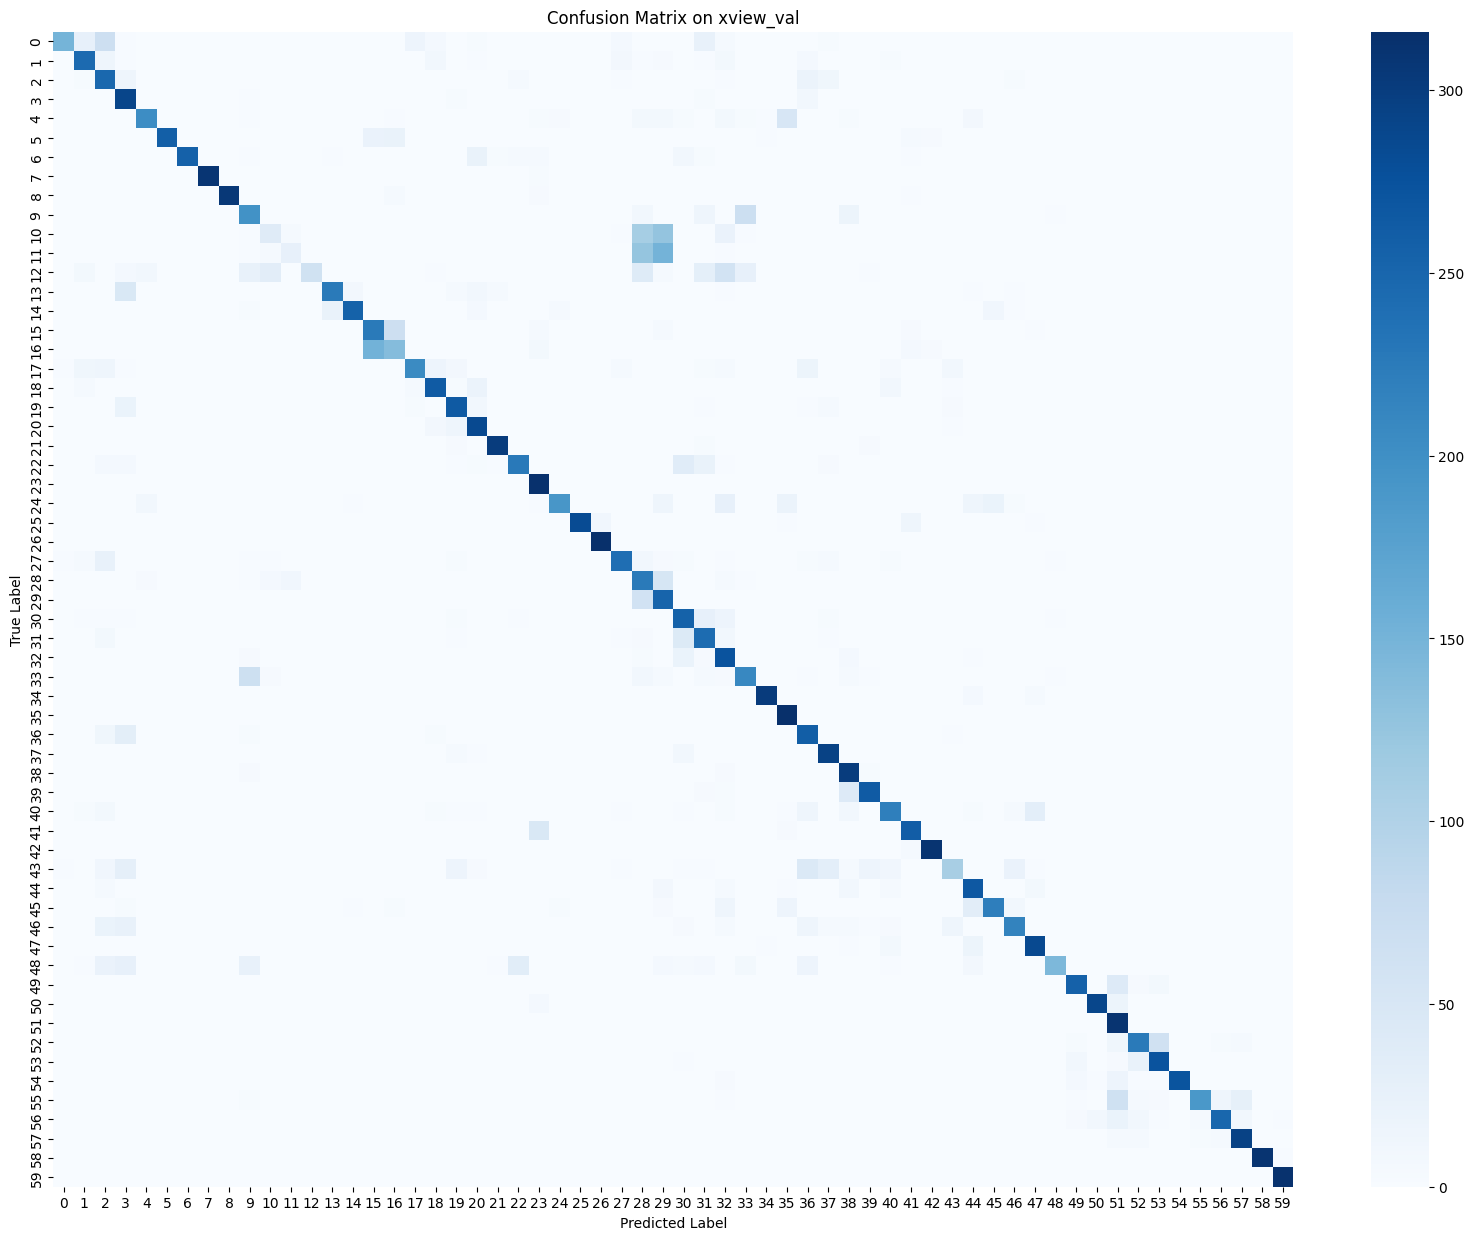

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def get_all_preds(model, dataloader, device):
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Collecting predictions"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(targets.numpy())
    return np.array(all_preds), np.array(all_labels)

# Get predictions for the test set
y_pred, y_true = get_all_preds(model, test_loader, device)

# Calculate per-class accuracy
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("--- Per-Class Accuracy ---")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc*100:.2f}%")

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
# Using the y_true and y_pred variables from the previous cell
report = classification_report(y_true, y_pred, digits=4)

print("--- Classification Report ---")
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9554    0.4747    0.6342       316
           1     0.7704    0.7753    0.7729       316
           2     0.5265    0.7848    0.6302       316
           3     0.5607    0.9209    0.6970       316
           4     0.8943    0.6424    0.7477       316
           5     0.9923    0.8196    0.8977       316
           6     0.9922    0.8101    0.8920       316
           7     0.9968    0.9810    0.9888       315
           8     1.0000    0.9652    0.9823       316
           9     0.5645    0.6234    0.5925       316
          10     0.4194    0.1238    0.1912       315
          11     0.5400    0.0857    0.1479       315
          12     0.9841    0.1962    0.3272       316
          13     0.8972    0.7184    0.7979       316
          14     0.9410    0.8070    0.8688       316
          15     0.5580    0.7175    0.6278       315
          16     0.5587    0.4367    0.4902       3

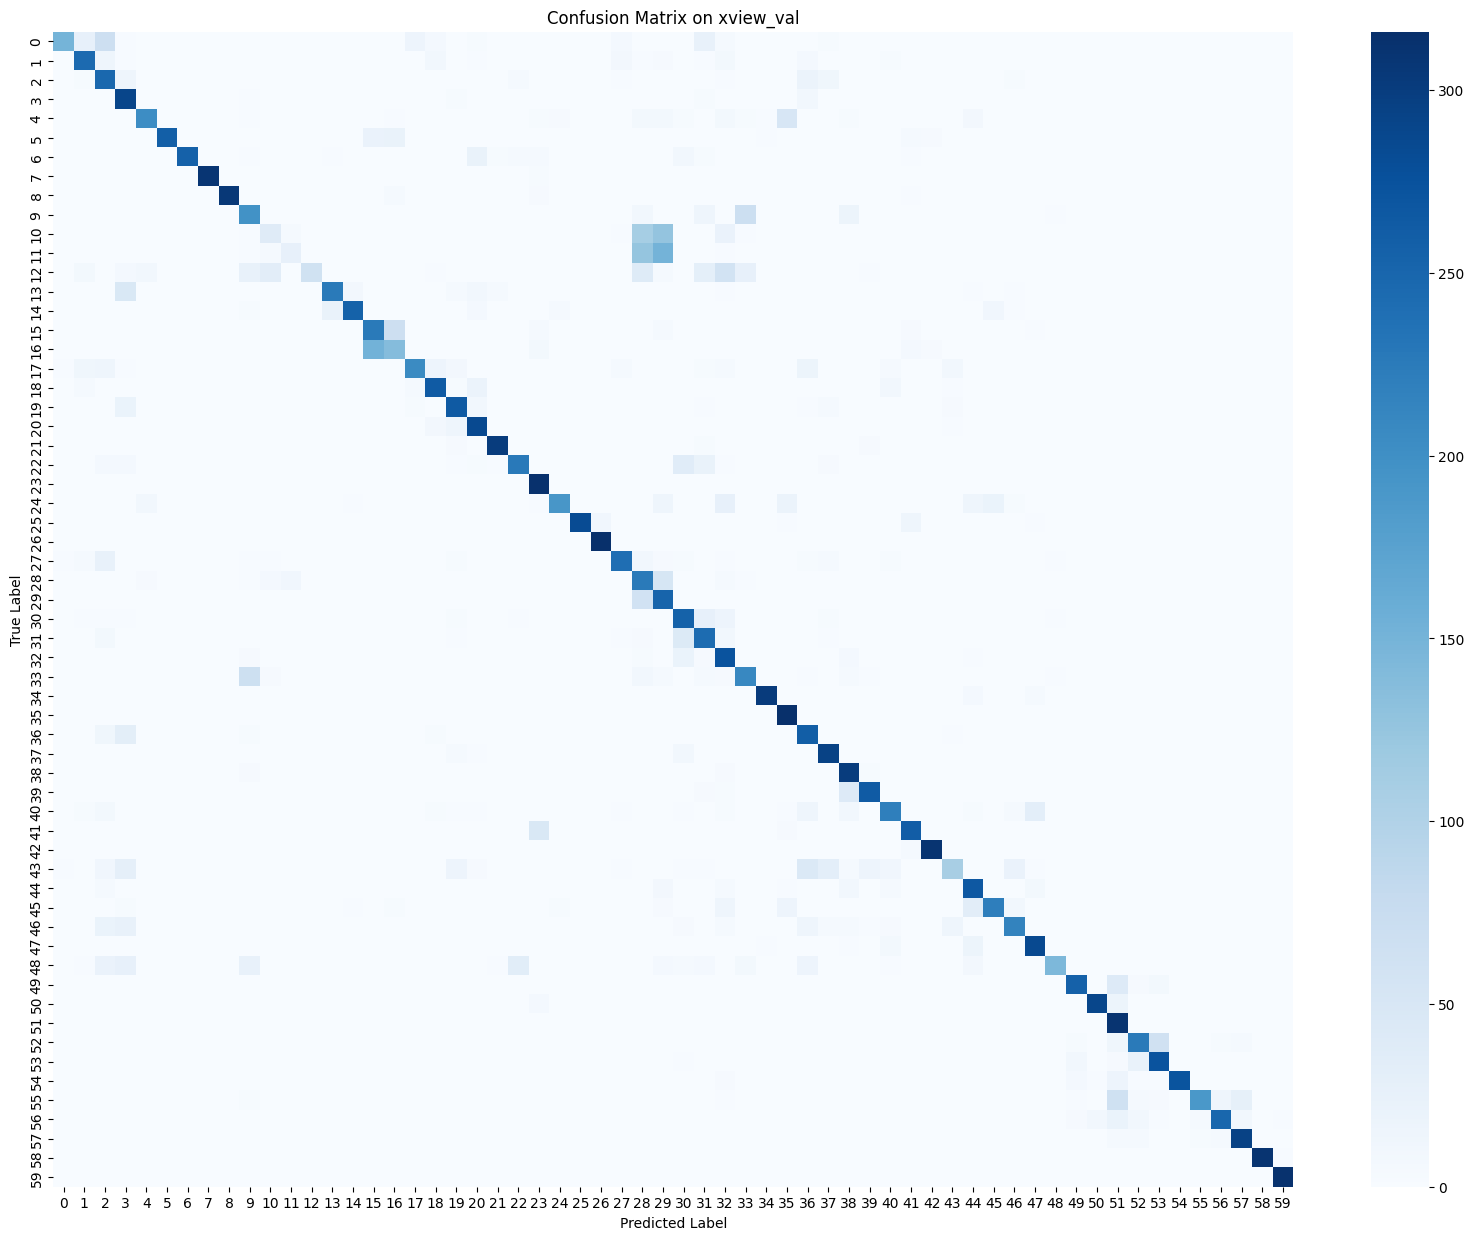

Confusion matrix saved as: confusion_matrix_test.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot and save
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix on xview_val')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save the figure to a file
file_path = 'confusion_matrix_test.png'
plt.savefig(file_path, bbox_inches='tight', dpi=300)
plt.show()

print(f'Confusion matrix saved as: {file_path}')